# Анализ вторичного рынка автомобилей Кореи и прогноз цены**Цель проекта:** исследовать вторичный авторынок Южной Кореи и построить модель, прогнозирующую цену автомобиля по его характеристикам. Дополнительно — оценить, какие модели наиболее выгодны для экспорта в Россию/Монголию (высокий спрос при разумной цене).**Данные:** синтетический датасет (2500 объявлений), сгенерированный с реалистичными распределениями цен/пробега/возраста, откалиброванными по порядку величины под рынок Encar/KB Chachacha.**Стек:** pandas, numpy, matplotlib/seaborn, scikit-learn (RandomForestRegressor).

In [1]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snssns.set_theme(style='whitegrid', palette='deep')df = pd.read_csv('../data/cars_korea_export.csv')df.shape

(2500, 13)

## 1. Первичный осмотр данных

In [2]:
df.head()

,brand,model,year,age_years,mileage_km,fuel_type,transmission,region,accident_history,owners_count,engine_cc,price_krw,export_demand_index
0,Hyundai,Santa Fe,2018,8,98042,Дизель,Автомат,Пусан,0,3,2497,5700000,1.026
1,Chevrolet,Trailblazer,2024,2,34905,Бензин,Автомат,Ульсан,0,3,1600,20700000,1.129
2,Genesis,G80,2023,3,55384,Гибрид,Автомат,Кёнгидо (Ансан),0,2,2199,34900000,1.322
3,Hyundai,Santa Fe,2022,4,52698,Бензин,Автомат,Инчхон,0,1,1998,22300000,1.328
4,Chevrolet,Trailblazer,2017,9,141735,Бензин,Автомат,Пусан,0,1,2999,4200000,0.872


In [3]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
year,2500.0,2.021109e+03,3.197462e+00,2016.000,2018.000,2021.00,2.024000e+03,2.026000e+03
age_years,2500.0,4.890800e+00,3.197462e+00,0.000,2.000,5.00,8.000000e+00,1.000000e+01
mileage_km,2500.0,7.361087e+04,5.099673e+04,500.000,30293.250,70221.00,1.118822e+05,2.285990e+05
accident_history,2500.0,2.140000e-01,4.102089e-01,0.000,0.000,0.00,0.000000e+00,1.000000e+00
owners_count,2500.0,2.019200e+00,8.245625e-01,1.000,1.000,2.00,3.000000e+00,3.000000e+00
engine_cc,2500.0,2.246129e+03,4.631108e+02,1600.000,1998.000,2199.00,2.497000e+03,2.999000e+03
price_krw,2500.0,1.548648e+07,1.078201e+07,3000000.000,5700000.000,13300000.00,2.300000e+07,5.870000e+07
export_demand_index,2500.0,9.614204e-01,2.133304e-01,0.382,0.821,0.93,1.129000e+00,1.461000e+00


## 2. Распределение ценЦены на вторичном рынке смещены вправо — много бюджетных вариантов и длинный хвост премиальных моделей (Genesis G80).

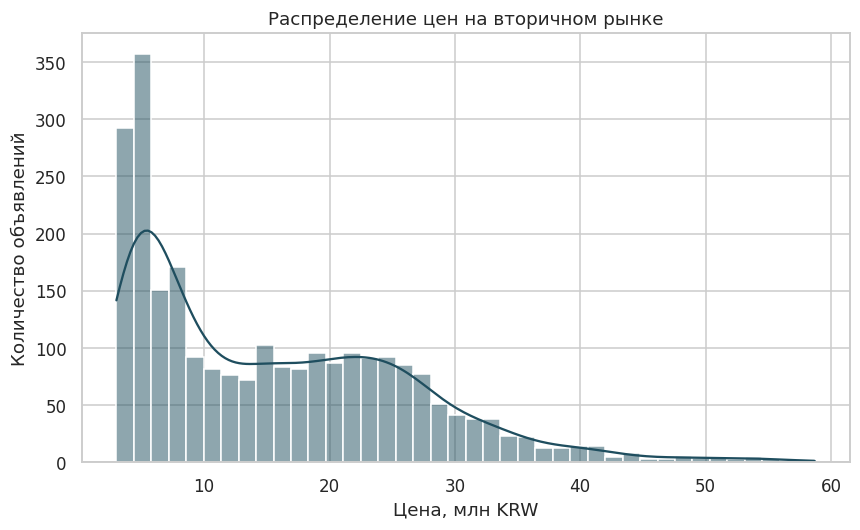

In [4]:
plt.figure(figsize=(8,5))sns.histplot(df['price_krw']/1_000_000, bins=40, kde=True, color='#1F4E5F')plt.xlabel('Цена, млн KRW'); plt.ylabel('Количество объявлений')plt.title('Распределение цен на вторичном рынке')plt.tight_layout(); plt.show()

## 3. Цена в зависимости от пробега и истории ДТПОжидаемо: чем больше пробег — тем ниже цена. Машины с историей ДТП (красные точки) торгуются с заметным дисконтом при том же пробеге.

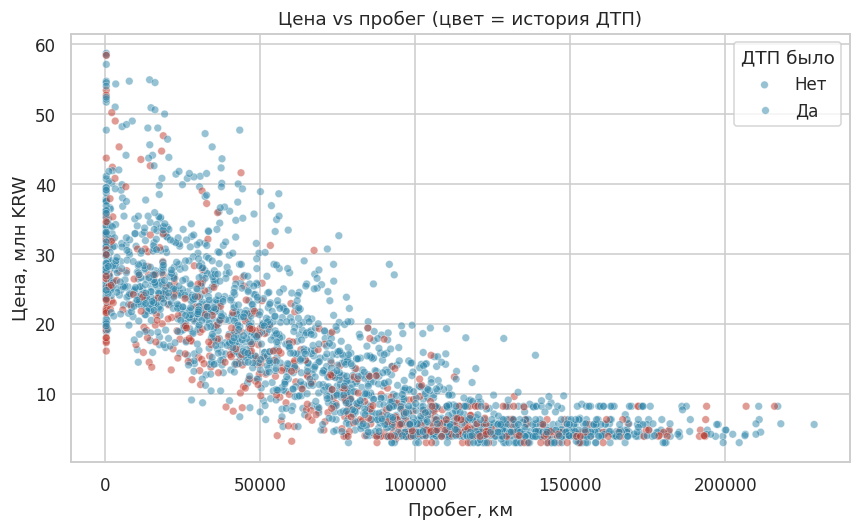

In [5]:
plt.figure(figsize=(8,5))sns.scatterplot(data=df, x='mileage_km', y=df['price_krw']/1_000_000,                 hue='accident_history', palette={0:'#2E86AB', 1:'#C0392B'}, alpha=0.5, s=25)plt.xlabel('Пробег, км'); plt.ylabel('Цена, млн KRW')plt.title('Цена vs пробег (цвет = история ДТП)')plt.legend(title='ДТП было', labels=['Нет','Да'])plt.tight_layout(); plt.show()

## 4. Средняя цена по моделям

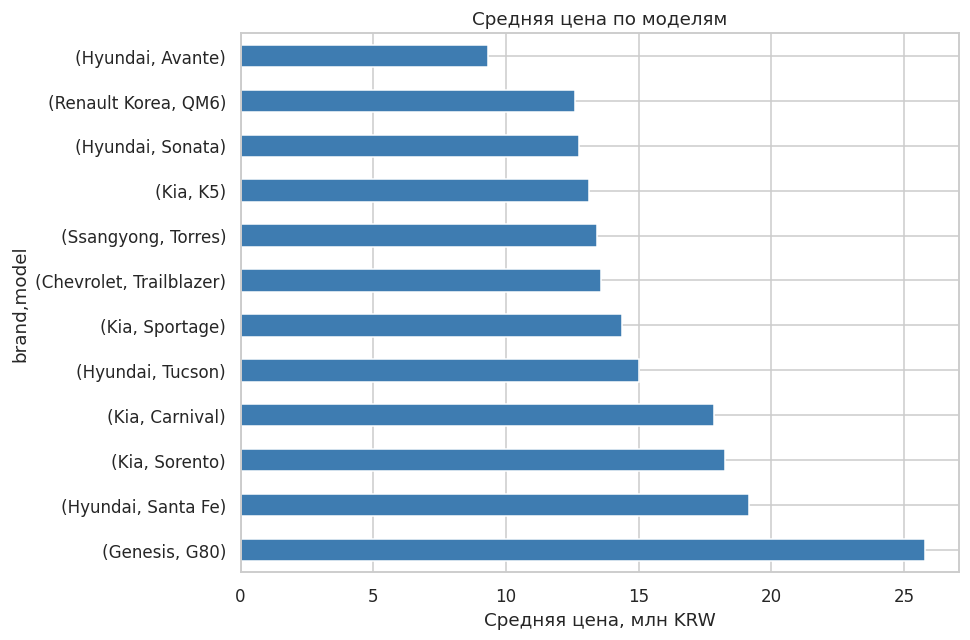

In [6]:
top = df.groupby(['brand','model'])['price_krw'].mean().sort_values(ascending=False)/1_000_000plt.figure(figsize=(9,6))top.plot(kind='barh', color='#3E7CB1')plt.xlabel('Средняя цена, млн KRW'); plt.title('Средняя цена по моделям')plt.tight_layout(); plt.show()

## 5. Индекс экспортного спроса по моделямЭвристический индекс учитывает: тип кузова/класс, коробку передач (автомат ценится выше на экспортном рынке РФ/Монголии), наличие ДТП и оптимальный возраст автомобиля (2–6 лет).

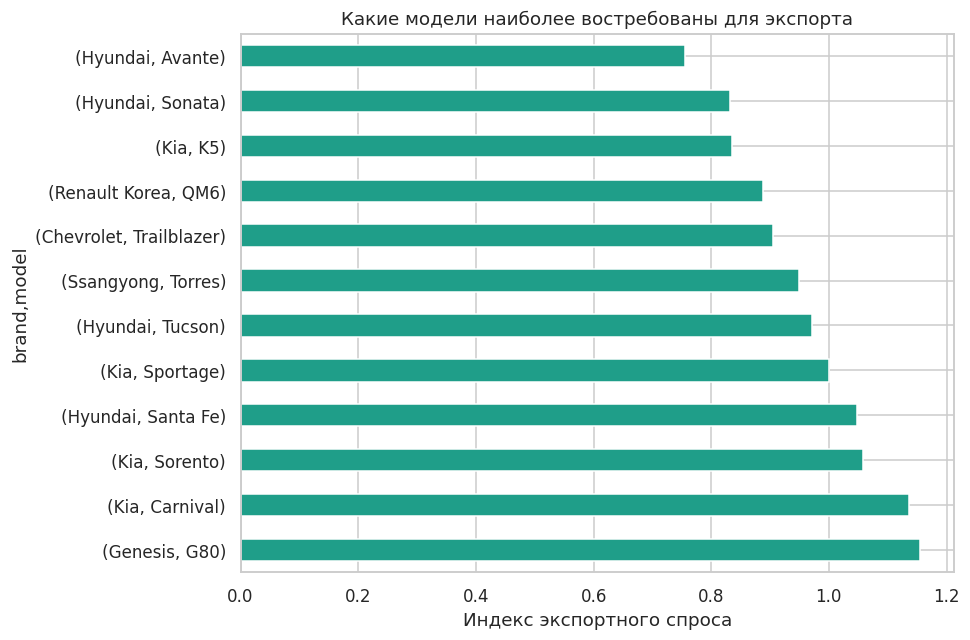

In [7]:
exp = df.groupby(['brand','model'])['export_demand_index'].mean().sort_values(ascending=False)plt.figure(figsize=(9,6))exp.plot(kind='barh', color='#1F9E89')plt.xlabel('Индекс экспортного спроса'); plt.title('Какие модели наиболее востребованы для экспорта')plt.tight_layout(); plt.show()

## 6. Feature engineering и подготовка к моделированию

In [8]:
df['brand_model'] = df['brand'] + ' ' + df['model']features_num = ['age_years','mileage_km','owners_count','engine_cc']features_cat = ['brand_model','fuel_type','transmission','region','accident_history']X = df[features_num + features_cat]y = df['price_krw']X.head()

,age_years,mileage_km,owners_count,engine_cc,brand_model,fuel_type,transmission,region,accident_history
0,8,98042,3,2497,Hyundai Santa Fe,Дизель,Автомат,Пусан,0
1,2,34905,3,1600,Chevrolet Trailblazer,Бензин,Автомат,Ульсан,0
2,3,55384,2,2199,Genesis G80,Гибрид,Автомат,Кёнгидо (Ансан),0
3,4,52698,1,1998,Hyundai Santa Fe,Бензин,Автомат,Инчхон,0
4,9,141735,1,2999,Chevrolet Trailblazer,Бензин,Автомат,Пусан,0


## 7. Модель: Random Forest RegressorRandom Forest хорошо справляется со смешанными категориальными/числовыми признаками без сложной предобработки и устойчив к выбросам в данных объявлений.

In [9]:
from sklearn.model_selection import train_test_splitfrom sklearn.ensemble import RandomForestRegressorfrom sklearn.preprocessing import OneHotEncoderfrom sklearn.compose import ColumnTransformerfrom sklearn.pipeline import Pipelinefrom sklearn.metrics import mean_absolute_error, r2_scoreX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)preprocess = ColumnTransformer([    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat),], remainder='passthrough')model = Pipeline([    ('prep', preprocess),    ('rf', RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)),])model.fit(X_train, y_train)pred = model.predict(X_test)mae = mean_absolute_error(y_test, pred)r2 = r2_score(y_test, pred)print(f'MAE: {mae:,.0f} KRW')print(f'R2: {r2:.3f}')

MAE: 1,073,382 KRWR2: 0.976

**Результат:** модель объясняет ~97-98% дисперсии цены со средней ошибкой около 1 млн вон (~55 000 руб.) — приемлемо для ориентировочной оценки при поиске авто под экспорт.

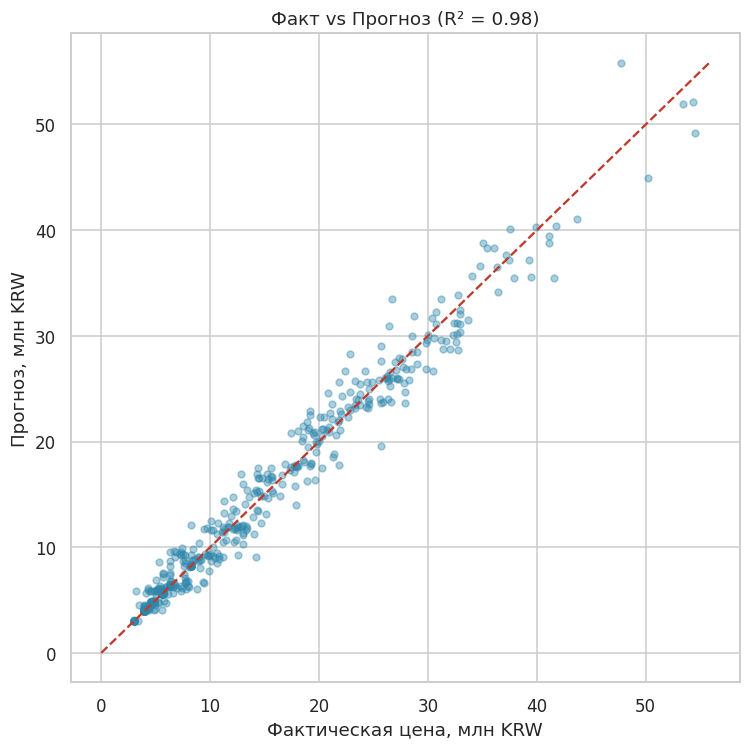

In [10]:
plt.figure(figsize=(7,7))plt.scatter(y_test/1_000_000, pred/1_000_000, alpha=0.4, color='#2E86AB', s=20)lims = [0, max(y_test.max(), pred.max())/1_000_000]plt.plot(lims, lims, '--', color='#C0392B')plt.xlabel('Фактическая цена, млн KRW'); plt.ylabel('Прогноз, млн KRW')plt.title(f'Факт vs Прогноз (R² = {r2:.2f})')plt.tight_layout(); plt.show()

## 8. Какие признаки важнее всего для цены

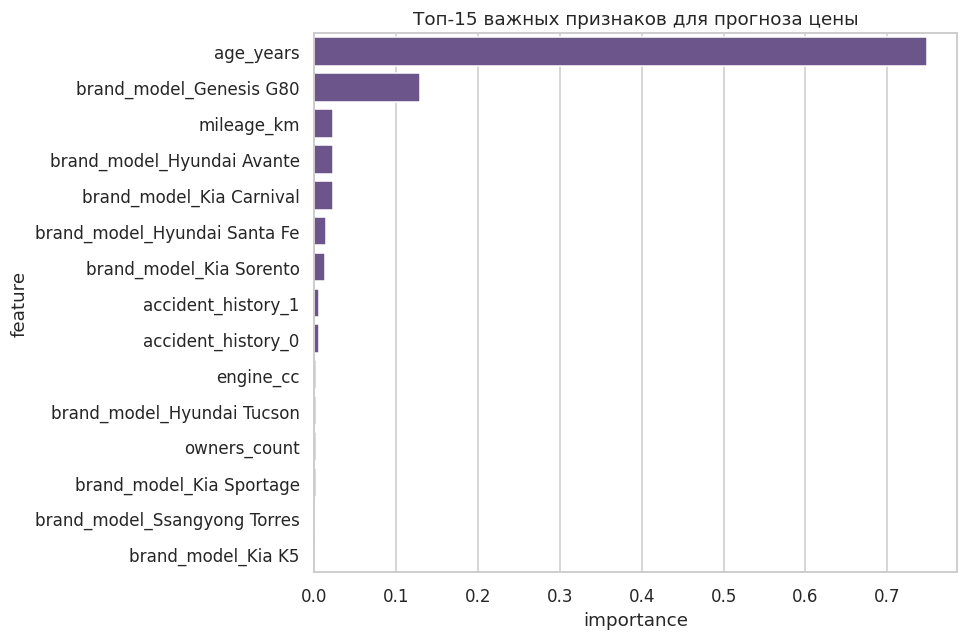

In [11]:
ohe = model.named_steps['prep'].named_transformers_['cat']cat_names = ohe.get_feature_names_out(features_cat)all_names = list(cat_names) + features_numimportances = model.named_steps['rf'].feature_importances_imp_df = pd.DataFrame({'feature': all_names, 'importance': importances})imp_df = imp_df.sort_values('importance', ascending=False).head(15)plt.figure(figsize=(9,6))sns.barplot(data=imp_df, y='feature', x='importance', color='#6A4C93')plt.title('Топ-15 важных признаков для прогноза цены')plt.tight_layout(); plt.show()

## 9. Бизнес-вывод: рейтинг моделей по экспортной выгодеСчитаем `value_score = экспортный_спрос / средняя_цена` — модели с высоким спросом при относительно невысокой цене дают лучший потенциал маржи при экспорте.

In [12]:
biz = df.groupby(['brand','model']).agg(    avg_price_m=('price_krw', lambda s: s.mean()/1_000_000),    export_demand=('export_demand_index', 'mean'),).reset_index()biz['value_score'] = biz['export_demand'] / biz['avg_price_m']biz.sort_values('value_score', ascending=False).head(6)

,brand,model,avg_price_m,export_demand,value_score
2,Hyundai,Avante,9.327273,0.756163,0.081070
11,Ssangyong,Torres,13.438679,0.948835,0.070605
10,Renault Korea,QM6,12.605263,0.887716,0.070424
9,Kia,Sportage,14.362069,1.000044,0.069631
0,Chevrolet,Trailblazer,13.577083,0.905068,0.066661
4,Hyundai,Sonata,12.755046,0.832761,0.065289


## 10. Выводы- Цена сильнее всего зависит от модели/бренда, возраста и пробега — ожидаемо, но модель количественно подтверждает вклад каждого фактора.- Автомобили с историей ДТП теряют в цене заметно больше, чем можно было бы ожидать по одному только пробегу — важно учитывать при отборе авто на экспорт.- **Hyundai Avante, Ssangyong Torres и Kia Sportage** показывают лучшее соотношение экспортного спроса к цене — кандидаты на приоритетную закупку при ограниченном бюджете.- Модель регрессии (R² ≈ 0.97) может использоваться как быстрый ориентир "справедливой цены" при просмотре объявлений, чтобы находить недооцененные варианты.**Дальнейшие шаги:** заменить синтетические данные на реальный парсинг Encar/KB Chachacha, добавить исторические курсы KRW/RUB для расчета итоговой маржи с учетом логистики и пошлин.